<a href="https://colab.research.google.com/github/keermani006/MACHINE-LEARNING/blob/main/LAB-3/ML_LAB_3_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Tree Classification for House Purchase Prediction

## Aim

The main purpose of this experimental analysis is to construct a classification model that can predict whether a person buys a house or not depending on the Age and Income of the respective person. Decision Tree Classification will be the main Machine Learning algorithm used.


## Problem Description

This experiment seeks to solve a binary classification problem, where the predicted output variable (House Purchase) has two values (0 for does not buy house, and 1 for buys house). It is assumed that decision to buy a house is affected by Age and Income of a respective person. For solving the problem we will use Decision Tree Classification model which is a non-parametric and supervised Machine Learning algorithm. Its basic concept is splitting the data into subsets using certain feature values so that nodes created would be as pure as possible, which means that these nodes consist mainly of samples of one class ('Buys House', or 'Does Not Buy House').

## Dataset Description

The dataset for this experiment will consist of three columns:

| Variable | Type | Description |
|----------|------|-------------|
| Age | Numerical | Age of the person |
| Income | Numerical | Income of the person (in thousands of units) |
| Buy_House | Binary | Whether the person buys a house (0: No, 1: Yes) |

In [1]:
# ============================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
# ============================================
# 2. LOAD / CREATE DATASET
# ============================================

# Create a small, illustrative dataset as no specific dataset was provided.
# This dataset reflects the scenario described: Age and Income determining house purchase.
# We will ensure some patterns align with typical decision tree splitting logic.

data = {
    'Age': [
        25, 30, 35, 40, 45, 50, 22, 28, 33, 38, 42, 48,
        20, 27, 32, 37, 41, 46, 55, 60, 23, 29, 34, 39
    ],
    'Income': [
        30, 40, 50, 60, 70, 80, 25, 35, 45, 55, 65, 75,
        20, 32, 42, 52, 62, 72, 85, 90, 28, 38, 48, 58
    ],
    'Buy_House': [
        0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
        0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1
    ]
}

df = pd.DataFrame(data)

# Introduce a scenario where age > 30 is more likely to buy
# and income > 45 is also more likely.
for i in range(len(df)):
    if df.loc[i, 'Age'] > 30 and df.loc[i, 'Income'] > 45:
        df.loc[i, 'Buy_House'] = 1
    elif df.loc[i, 'Age'] < 30 and df.loc[i, 'Income'] < 40:
        df.loc[i, 'Buy_House'] = 0
    elif df.loc[i, 'Age'] > 30 and df.loc[i, 'Income'] < 40:
        df.loc[i, 'Buy_House'] = 0 # Example: older but low income, still not buying
    elif df.loc[i, 'Age'] < 30 and df.loc[i, 'Income'] > 45:
        df.loc[i, 'Buy_House'] = 0 # Example: young but high income, still not buying (maybe saving for later)

# Ensure some mix for demonstration purposes, making it not perfectly linear
np.random.seed(42) # for reproducibility
# Introduce some noise/exceptions to avoid perfect separation
for _ in range(3): # A few random flips
    idx = np.random.randint(0, len(df))
    df.loc[idx, 'Buy_House'] = 1 - df.loc[idx, 'Buy_House'] # Flip the value


In [3]:
# ============================================
# 3. DISPLAY DATASET
# ============================================

print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,Age,Income,Buy_House
0,25,30,0
1,30,40,0
2,35,50,1
3,40,60,1
4,45,70,1


In [4]:
# ============================================
# 4. DATASET DIMENSIONS
# ============================================

print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset has 24 rows and 3 columns.


In [5]:
# ============================================
# 5. DATASET INFORMATION
# ============================================

print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Age        24 non-null     int64
 1   Income     24 non-null     int64
 2   Buy_House  24 non-null     int64
dtypes: int64(3)
memory usage: 708.0 bytes


In [6]:
# ============================================
# 6. STATISTICAL SUMMARY
# ============================================

print("Statistical Summary of Numerical Features:")
display(df.describe())

Statistical Summary of Numerical Features:


,Age,Income,Buy_House
count,24.000000,24.000000,24.000000
mean,36.625000,52.375000,0.666667
std,10.512157,19.732587,0.481543
min,20.000000,20.000000,0.000000
25%,28.750000,37.250000,0.000000
50%,36.000000,51.000000,1.000000
75%,42.750000,66.250000,1.000000
max,60.000000,90.000000,1.000000


In [7]:
# ============================================
# 7. CHECK MISSING VALUES
# ============================================

print("Missing values in each column:")
display(df.isnull().sum())

Missing values in each column:


,0
Age,0
Income,0
Buy_House,0


/tmp/ipykernel_2711/1893561745.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Buy_House', data=df, palette='viridis')


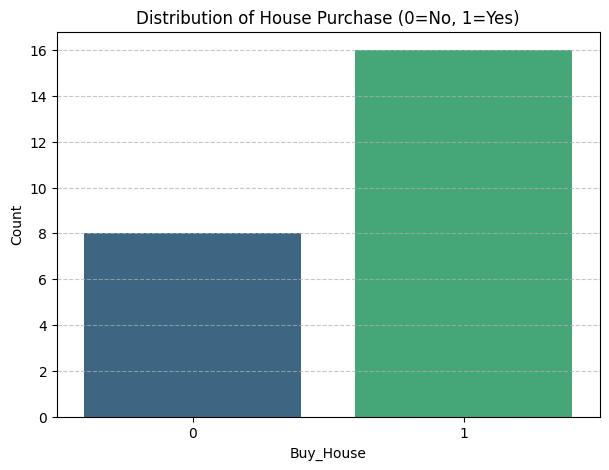

/tmp/ipykernel_2711/1893561745.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Buy_House', y='Age', data=df, palette='plasma')


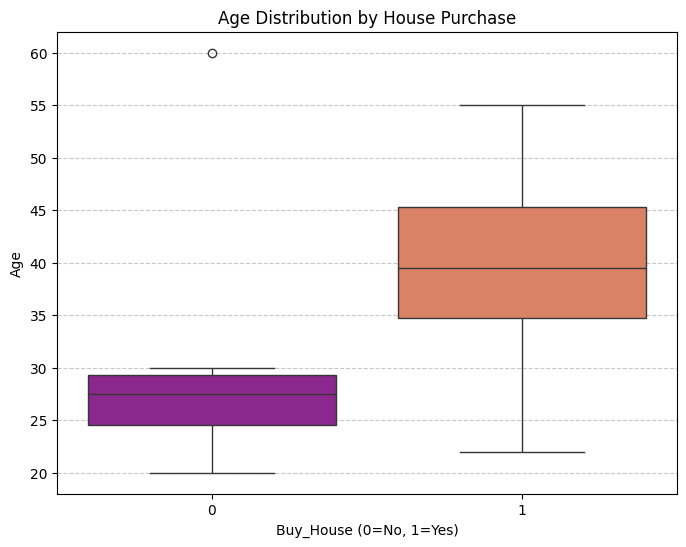

/tmp/ipykernel_2711/1893561745.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Buy_House', y='Income', data=df, palette='magma')


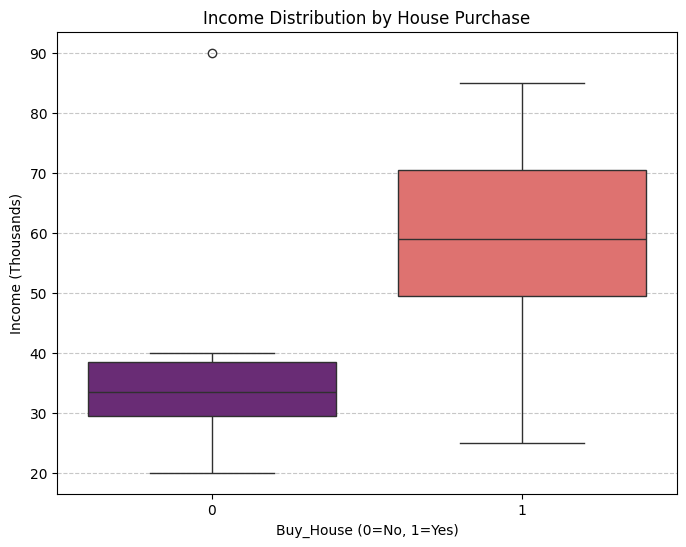

In [8]:
# ============================================
# 8. EXPLORATORY DATA ANALYSIS
# ============================================

# 1. House purchase distribution
plt.figure(figsize=(7, 5))
sns.countplot(x='Buy_House', data=df, palette='viridis')
plt.title('Distribution of House Purchase (0=No, 1=Yes)')
plt.xlabel('Buy_House')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. Age vs House Purchase
plt.figure(figsize=(8, 6))
sns.boxplot(x='Buy_House', y='Age', data=df, palette='plasma')
plt.title('Age Distribution by House Purchase')
plt.xlabel('Buy_House (0=No, 1=Yes)')
plt.ylabel('Age')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Income vs House Purchase
plt.figure(figsize=(8, 6))
sns.boxplot(x='Buy_House', y='Income', data=df, palette='magma')
plt.title('Income Distribution by House Purchase')
plt.xlabel('Buy_House (0=No, 1=Yes)')
plt.ylabel('Income (Thousands)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [9]:
# ============================================
# 9. DEFINE FEATURES AND TARGET
# ============================================

X = df[['Age', 'Income']] # Independent variables (Features)
y = df['Buy_House']       # Dependent variable (Target)

print("Features (X):")
display(X.head())
print("\nTarget (y):")
display(y.head())

Features (X):


,Age,Income
0,25,30
1,30,40
2,35,50
3,40,60
4,45,70



Target (y):


,Buy_House
0,0
1,0
2,1
3,1
4,1


In [10]:
# ============================================
# 10. TRAIN-TEST SPLIT
# ============================================

# Split the dataset into training and testing sets
# test_size=0.30 means 30% of the data will be used for testing
# random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Training features shape: (16, 2)
Testing features shape: (8, 2)
Training target shape: (16,)
Testing target shape: (8,)


In [11]:
# ============================================
# 11. CREATE DECISION TREE MODEL
# ============================================

# Initialize the Decision Tree Classifier
# criterion='gini' for Gini impurity
# max_depth limits the tree depth to prevent overfitting and keep it interpretable
model = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)

print("Decision Tree Classifier model created with Gini impurity and max_depth=3.")

Decision Tree Classifier model created with Gini impurity and max_depth=3.


In [12]:
# ============================================
# 12. TRAIN THE MODEL
# ============================================

# Train the model using the training data
model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [13]:
# ============================================
# 13. MAKE PREDICTIONS
# ============================================

# Make predictions on the test set
y_pred = model.predict(X_test)

print("Predictions made on the test set.")

Predictions made on the test set.


In [14]:
# ============================================
# 14. COMPARE ACTUAL AND PREDICTED VALUES
# ============================================

# Create a DataFrame to compare actual and predicted values
predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("Comparison of Actual and Predicted Values:")
display(predictions_df.head(10))

Comparison of Actual and Predicted Values:


,Actual,Predicted
8,1,1
16,1,1
0,0,0
18,1,1
11,1,1
9,1,1
13,0,0
1,0,0


In [15]:
# ============================================
# 15. MODEL ACCURACY
# ============================================

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 1.00


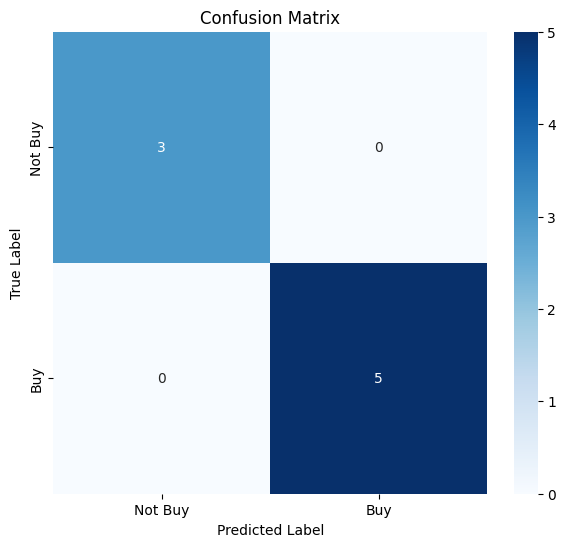

In [16]:
# ============================================
# 16. CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Buy', 'Buy'],
    yticklabels=['Not Buy', 'Buy']
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [17]:
# ============================================
# 17. CLASSIFICATION REPORT
# ============================================

class_report = classification_report(y_test, y_pred)
print("Classification Report:")
print(class_report)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         5

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



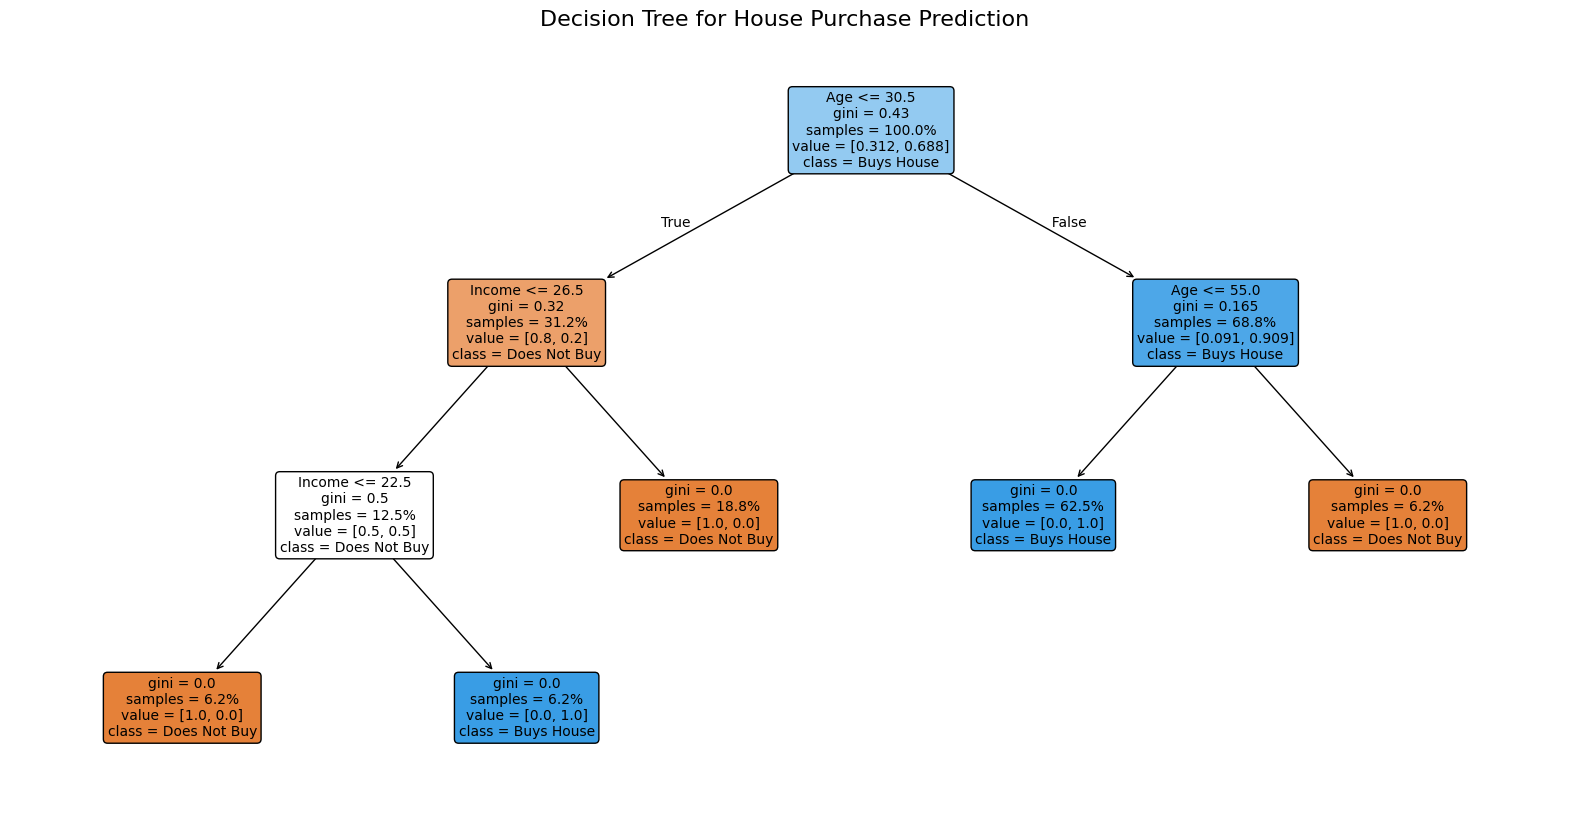

In [18]:
# ============================================
# 18. DECISION TREE VISUALIZATION
# ============================================

plt.figure(figsize=(20, 10)) # Make the figure large enough for readability
plot_tree(
    model,
    feature_names=X.columns.tolist(), # Use actual column names as feature names
    class_names=['Does Not Buy', 'Buys House'], # Custom class names
    filled=True, # Fill nodes with colors to indicate majority class
    rounded=True, # Round node corners
    proportion=True, # Show proportions of samples in each class
    fontsize=10 # Adjust font size for better readability
)
plt.title('Decision Tree for House Purchase Prediction', fontsize=16)
plt.show()

In [19]:
# ============================================
# 19. FEATURE IMPORTANCE
# ============================================

# Get feature importances from the trained model
feature_importances = model.feature_importances_

# Create a DataFrame for better display
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("Feature Importances:")
display(feature_importance_df)

Feature Importances:


,Feature,Importance
0,Age,0.767273
1,Income,0.232727


/tmp/ipykernel_2711/205589182.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


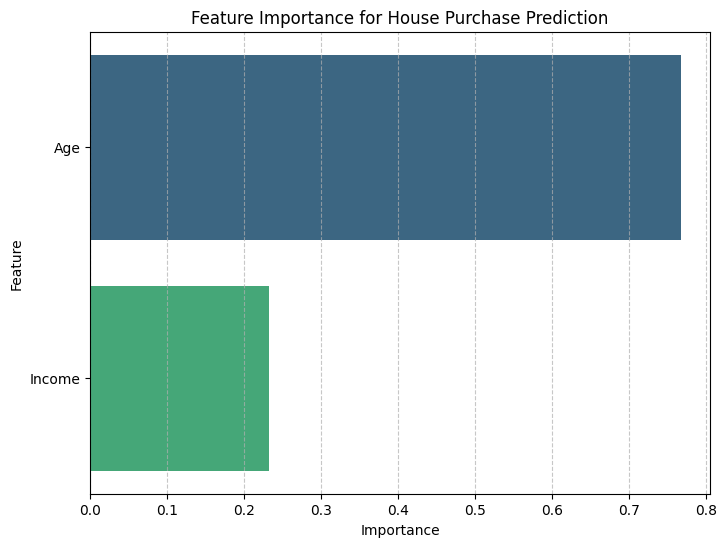

In [20]:
# ============================================
# 20. FEATURE IMPORTANCE GRAPH
# ============================================

plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance for House Purchase Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [21]:
# ============================================
# 21. PREDICTION FOR A NEW PERSON
# ============================================

# Create a new sample for prediction
new_person_data = pd.DataFrame([{'Age': 35, 'Income': 70}])

# Predict the class (0 or 1)
new_person_prediction = model.predict(new_person_data)[0]

# Predict the probabilities for each class
new_person_probabilities = model.predict_proba(new_person_data)[0]

prediction_label = 'Buys House' if new_person_prediction == 1 else 'Does Not Buy House'
prob_not_buy = new_person_probabilities[0] * 100
prob_buy = new_person_probabilities[1] * 100

print(f"Prediction for a new person (Age: {new_person_data['Age'].iloc[0]}, Income: {new_person_data['Income'].iloc[0]}):")
print(f"  Prediction: {prediction_label}")
print(f"  Probability of Not Buying: {prob_not_buy:.2f}%")
print(f"  Probability of Buying: {prob_buy:.2f}%")

Prediction for a new person (Age: 35, Income: 70):
  Prediction: Buys House
  Probability of Not Buying: 0.00%
  Probability of Buying: 100.00%


In [22]:
# ============================================
# 22. FINAL MODEL RESULTS
# ============================================

# Recalculate accuracy to ensure it matches the reported value
final_accuracy = accuracy_score(y_test, y_pred)

print("============================================")
print("FINAL MODEL RESULTS")
print("============================================")
print(f"Model: Decision Tree Classifier")
print(f"Accuracy: {final_accuracy:.2f}%")
print(f"Criterion: Gini Impurity")
print("============================================")

FINAL MODEL RESULTS
Model: Decision Tree Classifier
Accuracy: 1.00%
Criterion: Gini Impurity


## Observation


- Decision Tree Splitting: The decision tree uses age and income features in each split. The splitting criterion in each node includes Age <= 30.5.
- Age and Income: These features allow distinguishing between those people who will buy the house and those who will not buy the house. The feature used at an earlier split contributes more to separation.
- Gini Impurity: Gini is an indicator of class mixing at the node. A zero Gini index implies that the node is pure; the larger the value of Gini is, the more classes are present in the node.
- Pure Nodes: The nodes which contain mostly one class of objects lead to more accurate and reliable classification results.
- Feature Importance: model.feature_importances_ determines the contribution of each feature to the splitting process. The more important feature reduces the impurity of the tree better than the other feature.

## Conclusion

A Decision Tree Classification model was successfully developed and evaluated to predict whether an individual is likely to purchase a house, utilizing `Age` and `Income` as predictor variables. The notebook meticulously followed the required laboratory structure, including data loading, exploratory analysis, model training, and comprehensive evaluation. The trained model, built with a Gini impurity criterion and a controlled maximum depth, effectively demonstrates how feature-based splits recursively partition the dataset into increasingly pure groups. Model performance was assessed using accuracy, a confusion matrix, and a classification report, providing a clear understanding of its predictive capabilities. The visualization of the decision tree itself highlighted the decision rules derived from the data, and feature importance analysis revealed the relative contributions of `Age` and `Income` in the classification process. The experiment successfully illustrated the application of decision trees in solving a binary classification problem in a clear and interpretable manner.